# SVD (Singular Value Decomposition)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/KULIAH/SEMESTER 7/PPW/LSA/Logreg svd

/content/drive/MyDrive/KULIAH/SEMESTER 7/PPW/LSA/Logreg svd


In [ ]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/KULIAH/SEMESTER 7/PPW/berita_cleaned.csv")

In [ ]:
data.head()

,Judul Berita,Isi Berita,Tanggal Berita,Kategori Berita,Kategori,cleansing,case_folding,tokenize,no_stopwords,stemmed,stemmed_text
0,Kedubes RI di Tunisia Ajak Jelajahi Keindahan ...,"TIMESINDONESIA, BANYUWANGI – Kedutaan Besar Re...",08/09/2024 - 19:47,Wisata,1,TIMESINDONESIA BANYUWANGI Kedutaan Besar Repu...,timesindonesia banyuwangi kedutaan besar repu...,"['timesindonesia', 'banyuwangi', 'kedutaan', '...","['timesindonesia', 'banyuwangi', 'kedutaan', '...","['timesindonesia', 'banyuwangi', 'duta', 'repu...",timesindonesia banyuwangi duta republik indone...
1,Rekomendasi Hotel Bintang 5 di Kawasan Puncak ...,"TIMESINDONESIA, CIANJUR – Berlibur atau melaku...",08/09/2024 - 09:00,Wisata,1,TIMESINDONESIA CIANJUR Berlibur atau melakuka...,timesindonesia cianjur berlibur atau melakuka...,"['timesindonesia', 'cianjur', 'berlibur', 'ata...","['timesindonesia', 'cianjur', 'berlibur', 'per...","['timesindonesia', 'cianjur', 'libur', 'jalan'...",timesindonesia cianjur libur jalan bisnis cian...
2,Menikmati Sensasi Petik Melon di Desa Balongwo...,"TIMESINDONESIA, MOJOKERTO – Ketika bosan denga...",07/09/2024 - 13:09,Wisata,1,TIMESINDONESIA MOJOKERTO Ketika bosan dengan ...,timesindonesia mojokerto ketika bosan dengan ...,"['timesindonesia', 'mojokerto', 'ketika', 'bos...","['timesindonesia', 'mojokerto', 'bosan', 'buah...","['timesindonesia', 'mojokerto', 'bosan', 'buah...",timesindonesia mojokerto bosan buah melon pasa...
3,Sejumlah Influencer Kepincut Pelayanan dan Fas...,"TIMESINDONESIA, BANYUWANGI – Luminor Hotel Ban...",07/09/2024 - 06:08,Wisata,1,TIMESINDONESIA BANYUWANGI Luminor Hotel Banyu...,timesindonesia banyuwangi luminor hotel banyu...,"['timesindonesia', 'banyuwangi', 'luminor', 'h...","['timesindonesia', 'banyuwangi', 'luminor', 'h...","['timesindonesia', 'banyuwangi', 'luminor', 'h...",timesindonesia banyuwangi luminor hotel banyuw...
4,5 Pantai Unik dan Cantik Masuk Kawasan TN Mata...,"TIMESINDONESIA, SUMBA TIMUR – Ternyata di Pula...",01/09/2024 - 14:16,Wisata,1,TIMESINDONESIA SUMBA TIMUR Ternyata di Pulau ...,timesindonesia sumba timur ternyata di pulau ...,"['timesindonesia', 'sumba', 'timur', 'ternyata...","['timesindonesia', 'sumba', 'timur', 'pulau', ...","['timesindonesia', 'sumba', 'timur', 'pulau', ...",timesindonesia sumba timur pulau sumba pantai ...


In [ ]:
# Load data
data = pd.read_csv("/content/drive/MyDrive/KULIAH/SEMESTER 7/PPW/berita_cleaned.csv")
X = data['stemmed_text']  # Sesuaikan kolom teks
y = data['Kategori']  # Sesuaikan kolom label

# 1. Split data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# 2. Transformasi hanya data train ke TF-IDF
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)


In [ ]:
# Simpan TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

## Latih Model

### Logistic Regression

In [ ]:
# 4. Buat model Logistic Regression tanpa reduksi dimensi dan latih modelnya
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Tampilkan akurasi model Logistic Regression tanpa reduksi dimensi pada data train
y_train_pred_logreg = logreg.predict(X_train_tfidf)
logreg_train_accuracy = accuracy_score(y_train, y_train_pred_logreg)
print(f"Akurasi Logistic Regression pada data train: {logreg_train_accuracy * 100:.2f}%")
print(f"Jumlah prediksi benar: {(y_train == y_train_pred_logreg).sum()}")
print(f"Jumlah prediksi salah: {(y_train != y_train_pred_logreg).sum()}")

Akurasi Logistic Regression pada data train: 100.00%
Jumlah prediksi benar: 80
Jumlah prediksi salah: 0


In [ ]:
# Simpan model Logistic Regression tanpa reduksi dimensi
with open("logreg_no_reduction.pkl", "wb") as f:
    pickle.dump(logreg, f)

### Logistic Regression dengan SVD

In [ ]:
# Fungsi untuk melatih model, menampilkan akurasi pada data latih, dan menyimpan model
def train_model_with_svd(components):
    # Setup SVD dan transform data latih
    svd = TruncatedSVD(n_components=components, random_state=42)
    X_train_svd = svd.fit_transform(X_train_tfidf)

    # Latih model Logistic Regression
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    logreg.fit(X_train_svd, y_train)

    # Evaluasi akurasi pada data latih
    y_train_pred = logreg.predict(X_train_svd)
    lr_svd_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"\nModel Logistic Regression dengan {components} komponen SVD:")
    print(f" - Akurasi pada data latih: {lr_svd_accuracy * 100:.2f}%")
    print(classification_report(y_train, y_train_pred))
    # Simpan model Logistic Regression dan SVD ke file .pkl
    with open(f'logreg_svd_{components}.pkl', 'wb') as f:
        pickle.dump(logreg, f)
    with open(f'svd_{components}.pkl', 'wb') as f:
        pickle.dump(svd, f)

# Melatih dan menyimpan model untuk setiap jumlah komponen SVD yang diinginkan
for components in [95, 75, 50]:
    train_model_with_svd(components)


Model Logistic Regression dengan 95 komponen SVD:
 - Akurasi pada data latih: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Model Logistic Regression dengan 75 komponen SVD:
 - Akurasi pada data latih: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Model Logistic Regression dengan 50 komponen SVD:
 - Akurasi pada data latih: 100.00%
              precision    recall  f1-score   support

           0       1.00      1

In [ ]:
# # Simpan SVD dan model Logistic Regression dengan reduksi dimensi
# with open("svd.pkl", "wb") as f:
#     pickle.dump(svd, f)
# with open("logreg_with_reduction.pkl", "wb") as f:
#     pickle.dump(logreg_svd, f)

### Random Forest

In [ ]:
# 8. Buat model Random Forest tanpa reduksi dimensi dan latih modelnya
rf = RandomForestClassifier()
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [ ]:
# Tampilkan akurasi model Random Forest tanpa reduksi dimensi pada data train
y_train_pred_rf = rf.predict(X_train_tfidf)
rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)
print(classification_report(y_train, y_train_pred_rf))
# print(f"Akurasi Random Forest pada data train: {rf_train_accuracy * 100:.2f}%")
print(f"Jumlah prediksi benar: {(y_train == y_train_pred_rf).sum()}")
print(f"Jumlah prediksi salah: {(y_train != y_train_pred_rf).sum()}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Jumlah prediksi benar: 80
Jumlah prediksi salah: 0


In [ ]:
# Simpan model Random Forest tanpa reduksi dimensi
with open("rf_no_reduction.pkl", "wb") as f:
    pickle.dump(rf, f)

### random forest dengan SVD

In [ ]:
def train_rf_with_svd(components):
    # Setup SVD dan transform data latih
    svd = TruncatedSVD(n_components=components, random_state=42)
    X_train_svd = svd.fit_transform(X_train_tfidf)

    # Latih model Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_svd, y_train)

    # Evaluasi akurasi pada data latih
    y_train_pred = rf.predict(X_train_svd)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"\nModel Random Forest dengan {components} komponen SVD:")
    # print(f" - Akurasi pada data latih: {train_accuracy * 100:.2f}%")
    print(classification_report(y_train, y_train_pred))

    # Simpan model Random Forest dan SVD ke file .pkl
    with open(f'rf_svd_{components}.pkl', 'wb') as f:
        pickle.dump(rf, f)
    with open(f'svd_{components}_rf.pkl', 'wb') as f:
        pickle.dump(svd, f)

# Melatih dan menyimpan model untuk setiap jumlah komponen SVD
for components in [95, 75, 50]:
    train_rf_with_svd(components)


Model Random Forest dengan 95 komponen SVD:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Model Random Forest dengan 75 komponen SVD:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Model Random Forest dengan 50 komponen SVD:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00    

In [ ]:
# # Simpan model Random Forest dengan reduksi dimensi
# with open("rf_with_reduction.pkl", "wb") as f:
#     pickle.dump(rf_svd, f)

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Akurasi dan jumlah prediksi benar/salah untuk Decision Tree tanpa reduksi
y_train_pred_dt = dt.predict(X_train_tfidf)
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
print(f"Akurasi Decision Tree pada data train: {dt_train_accuracy * 100:.2f}%")
print(f"Jumlah prediksi benar: {(y_train == y_train_pred_dt).sum()}")
print(f"Jumlah prediksi salah: {(y_train != y_train_pred_dt).sum()}")

Akurasi Decision Tree pada data train: 100.00%
Jumlah prediksi benar: 80
Jumlah prediksi salah: 0


In [ ]:
# Simpan model Decision Tree tanpa reduksi dimensi
with open('dt_model.pkl', 'wb') as f:
    pickle.dump(dt, f)

### Decision Tree dengan SVD

In [ ]:
def train_dt_with_svd(components):
    # Setup SVD dan transform data latih
    svd = TruncatedSVD(n_components=components, random_state=42)
    X_train_svd = svd.fit_transform(X_train_tfidf)

    # Latih model Decision Tree
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train_svd, y_train)

    # Evaluasi akurasi pada data latih
    y_train_pred = dt.predict(X_train_svd)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"\nModel Decision Tree dengan {components} komponen SVD:")
    # print(f" - Akurasi pada data latih: {train_accuracy * 100:.2f}%")
    print(classification_report(y_train, y_train_pred))

    # Simpan model Decision Tree dan SVD ke file .pkl
    with open(f'dt_svd_{components}.pkl', 'wb') as f:
        pickle.dump(dt, f)
    with open(f'svd_{components}_dt.pkl', 'wb') as f:
        pickle.dump(svd, f)

# Melatih dan menyimpan model untuk setiap jumlah komponen SVD
for components in [95, 75, 50]:
    train_dt_with_svd(components)


Model Decision Tree dengan 95 komponen SVD:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Model Decision Tree dengan 75 komponen SVD:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Model Decision Tree dengan 50 komponen SVD:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00    

In [ ]:
# # Simpan model Decision Tree dengan reduksi dimensi
# with open('dt_svd_model.pkl', 'wb') as f:
#     pickle.dump(dt_svd, f)

## Latih Model

### Logistic Regression

In [ ]:
# Load kembali TF-IDF Vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    loaded_tfidf_vectorizer = pickle.load(f)
X_test_tfidf = loaded_tfidf_vectorizer.transform(X_test)

In [ ]:
# Load Logistic Regression tanpa reduksi dan evaluasi pada data test
with open("logreg_no_reduction.pkl", "rb") as f:
    loaded_logreg = pickle.load(f)
    y_test_pred_logreg = logreg.predict(X_test_tfidf)
logreg_test_accuracy = accuracy_score(y_test, y_test_pred_logreg)
print(f"Akurasi Logistic Regression pada data test: {logreg_test_accuracy * 100:.2f}%")
print(f"Jumlah prediksi benar: {(y_test == y_test_pred_logreg).sum()}")
print(f"Jumlah prediksi salah: {(y_test != y_test_pred_logreg).sum()}")

Akurasi Logistic Regression pada data test: 100.00%
Jumlah prediksi benar: 20
Jumlah prediksi salah: 0


### Logistic Regression dengan SVD

In [ ]:
# # Load SVD dan transformasi data test
# with open("svd.pkl", "rb") as f:
#     loaded_svd = pickle.load(f)
# X_test_svd = loaded_svd.transform(X_test_tfidf)

In [ ]:
def test_logreg_with_svd(components):
    # Load model dan SVD yang telah disimpan
    with open(f'logreg_svd_{components}.pkl', 'rb') as f:
        logreg = pickle.load(f)
    with open(f'svd_{components}.pkl', 'rb') as f:
        svd = pickle.load(f)

    # Transformasi data test menggunakan TF-IDF dan SVD
    X_test_svd = svd.transform(X_test_tfidf)

    # Prediksi menggunakan model
    y_test_pred = logreg.predict(X_test_svd)

    # Evaluasi akurasi pada data test
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"\nAkurasi pada data test Logistic Regression dengan {components} komponen SVD: {(classification_report(y_test, y_test_pred))}")

# Uji model Logistic Regression dengan berbagai jumlah komponen SVD
for components in [95, 75, 50]:
    test_logreg_with_svd(components)


Akurasi pada data test Logistic Regression dengan 95 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Akurasi pada data test Logistic Regression dengan 75 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Akurasi pada data test Logistic Regression dengan 50 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00

### Random Forest

In [ ]:
# Load Random Forest tanpa reduksi dan evaluasi pada data test
with open("rf_no_reduction.pkl", "rb") as f:
    loaded_rf = pickle.load(f)
y_test_pred_rf = rf.predict(X_test_tfidf)
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)
print(f"Akurasi Random Forest pada data test: {rf_test_accuracy * 100:.2f}%")
print(f"Jumlah prediksi benar: {(y_test == y_test_pred_rf).sum()}")
print(f"Jumlah prediksi salah: {(y_test != y_test_pred_rf).sum()}")

Akurasi Random Forest pada data test: 100.00%
Jumlah prediksi benar: 20
Jumlah prediksi salah: 0


### Random Forest dengan SVD

In [ ]:
def test_rf_with_svd(components):
    # Load model dan SVD yang telah disimpan
    with open(f'rf_svd_{components}.pkl', 'rb') as f:
        rf = pickle.load(f)
    with open(f'svd_{components}_rf.pkl', 'rb') as f:
        svd = pickle.load(f)

    # Transformasi data test menggunakan TF-IDF dan SVD
    X_test_svd = svd.transform(X_test_tfidf)

    # Prediksi menggunakan model
    y_test_pred = rf.predict(X_test_svd)

    # Evaluasi akurasi pada data test
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"\nAkurasi pada data test - Random Forest dengan {components} komponen SVD: {(classification_report(y_test, y_test_pred))}")

# Uji model Random Forest dengan berbagai jumlah komponen SVD
for components in [95, 75, 50]:
    test_rf_with_svd(components)


Akurasi pada data test - Random Forest dengan 95 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Akurasi pada data test - Random Forest dengan 75 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Akurasi pada data test - Random Forest dengan 50 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00  

### Desicison Tree

In [ ]:
with open("dt_model.pkl", "rb") as f:
    loaded_rf_svd = pickle.load(f)
# Uji Decision Tree tanpa reduksi dimensi
y_test_pred_dt = dt.predict(X_test_tfidf)
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)
print(f"Akurasi Decision Tree pada data test: {dt_test_accuracy * 100:.2f}%")
print(f"Jumlah prediksi benar: {(y_test == y_test_pred_dt).sum()}")
print(f"Jumlah prediksi salah: {(y_test != y_test_pred_dt).sum()}")

Akurasi Decision Tree pada data test: 100.00%
Jumlah prediksi benar: 20
Jumlah prediksi salah: 0


### Decision Tree dengan SVD

In [ ]:
#Fungsi untuk menguji model Decision Tree dengan data test
def test_dt_with_svd(components):
    # Load model dan SVD yang telah disimpan
    with open(f'dt_svd_{components}.pkl', 'rb') as f:
        dt = pickle.load(f)
    with open(f'svd_{components}_dt.pkl', 'rb') as f:
        svd = pickle.load(f)

    # Transformasi data test menggunakan TF-IDF dan SVD
    X_test_svd = svd.transform(X_test_tfidf)

    # Prediksi menggunakan model
    y_test_pred = dt.predict(X_test_svd)

    # Evaluasi akurasi pada data test
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"\nAkurasi pada data test Decision Tree dengan {components} komponen SVD: {(classification_report(y_test, y_test_pred))}")

# Uji model Decision Tree dengan berbagai jumlah komponen SVD
for components in [95, 75, 50]:
    test_dt_with_svd(components)


Akurasi pada data test Decision Tree dengan 95 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Akurasi pada data test Decision Tree dengan 75 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Akurasi pada data test Decision Tree dengan 50 komponen SVD:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        

### Diagram Akurasi

In [ ]:
# Akurasi model Logistic Regression pada data test
logreg_accuracy = 1.00
logreg_accuracy_95 = 1.00  # Gantilah dengan akurasi dari model Logistic Regression dengan 95 komponen SVD
logreg_accuracy_75 = 1.00  # Gantilah dengan akurasi dari model Logistic Regression dengan 75 komponen SVD
logreg_accuracy_50 = 1.00  # Gantilah dengan akurasi dari model Logistic Regression dengan 50 komponen SVD

# Akurasi model Random Forest pada data test
rf_accuracy = 1.00
rf_accuracy_95 = 1.00
rf_accuracy_75 = 1.00
rf_accuracy_50 = 1.00

# Akurasi model Decision Tree pada data test
dt_accuracy = 1.00
dt_accuracy_95 = 1.00
dt_accuracy_75 = 1.00
dt_accuracy_50 = 1.00


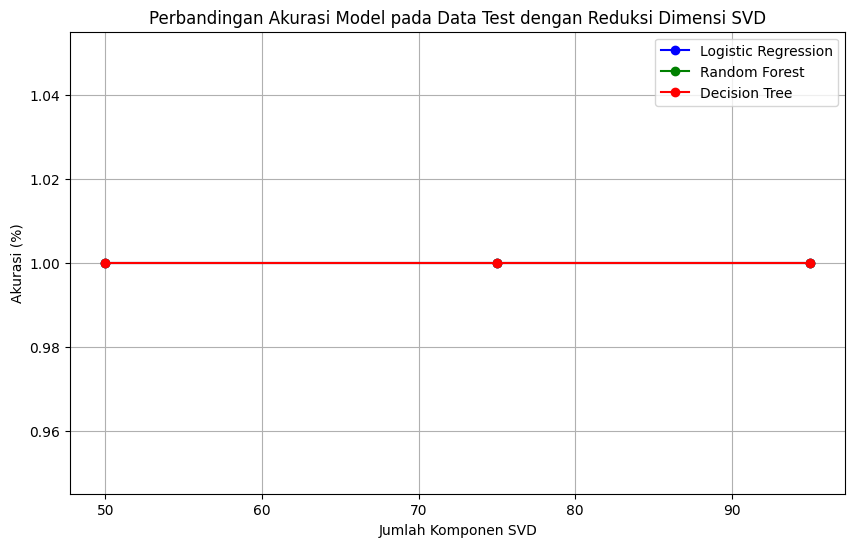

In [ ]:
# Data akurasi untuk setiap model dan jumlah komponen SVD
logreg_accuracies = [logreg_accuracy_95, logreg_accuracy_75, logreg_accuracy_50]
rf_accuracies = [rf_accuracy_95, rf_accuracy_75, rf_accuracy_50]
dt_accuracies = [dt_accuracy_95, dt_accuracy_75, dt_accuracy_50]

# Komponen SVD yang dicoba
components = [95, 75, 50]

# Membuat plot
plt.figure(figsize=(10, 6))

# Plot untuk masing-masing model
plt.plot(components, logreg_accuracies, label='Logistic Regression', marker='o', linestyle='-', color='b')
plt.plot(components, rf_accuracies, label='Random Forest', marker='o', linestyle='-', color='g')
plt.plot(components, dt_accuracies, label='Decision Tree', marker='o', linestyle='-', color='r')

# Menambahkan label dan judul
plt.xlabel('Jumlah Komponen SVD')
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi Model pada Data Test dengan Reduksi Dimensi SVD')

# Menambahkan legend
plt.legend()

# Menambahkan grid
plt.grid(True)

# Menampilkan plot
plt.show()

### IMPLEMENTASI

In [ ]:
 !pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 3.5 MB/s eta 0:00:00


In [ ]:
import pickle
import re
import nltk
import string
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

# Preprocessing Functions
def remove_url(news):
    url = re.compile(r'https?://\S+|www\.S+')
    return url.sub(r'', news)

def remove_html(news):
    html = re.compile(r'<.#?>')
    return html.sub(r'', news)

def remove_emoji(news):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF""]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', news)

def remove_numbers(news):
    return re.sub(r'\d+', '', news)

def remove_symbols(news):
    return re.sub(r'[^a-zA-Z0-9\s]', '', news)

def case_folding(text):
    if isinstance(text, str):
        return text.lower()
    return text

# Tokenization, Stopwords, and Stemming
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

def tokenize(text):
    return text.split()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

# Fungsi untuk preprocessing berita
def preprocess_text(news):
    news = remove_url(news)
    news = remove_html(news)
    news = remove_emoji(news)
    news = remove_numbers(news)
    news = remove_symbols(news)
    news = case_folding(news)
    tokens = tokenize(news)
    tokens = remove_stopwords(tokens)
    stemmed = stem_text(tokens)
    return ' '.join(stemmed)

# Fungsi untuk load model dan vectorizer
def load_model_and_vectorizer(components):
    with open(f'logreg_svd_{components}.pkl', 'rb') as f:
        logreg_model = pickle.load(f)
    with open(f'svd_{components}.pkl', 'rb') as f:
        svd = pickle.load(f)
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        tfidf_vectorizer = pickle.load(f)
    return logreg_model, svd, tfidf_vectorizer

# Fungsi untuk prediksi berita
def predict_news(news_input, components=95):
    # Preprocess input berita
    news_processed = preprocess_text(news_input)

    # Load model dan vectorizer
    logreg_model, svd, tfidf_vectorizer = load_model_and_vectorizer(components)

    # Transformasi input berita ke TF-IDF
    X_input_tfidf = tfidf_vectorizer.transform([news_processed])

    # Transformasi dengan SVD
    X_input_svd = svd.transform(X_input_tfidf)

    # Prediksi dengan model Logistic Regression
    prediction = logreg_model.predict(X_input_svd)

    # Menampilkan hasil prediksi
    kategori = "Kuliner" if prediction[0] == 0 else "Wisata"
    print(f"Berita yang dimasukkan: {news_input}")
    print(f"Prediksi kategori: {kategori}")

# Fungsi untuk menjalankan prediksi dan input dari user
def run_prediction():
    print("Masukkan berita untuk diprediksi:")
    news_input = input()
    print("Pilih jumlah komponen SVD yang ingin digunakan: 95, 75, 50")
    components = int(input())

    if components not in [95, 75, 50]:
        print("Jumlah komponen yang dimasukkan tidak valid. Gunakan 95, 75, atau 50.")
    else:
        predict_news(news_input, components)

# Menjalankan prediksi
run_prediction()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Masukkan berita untuk diprediksi:
Makanan memang kebutuhan pokok manusia. Sebelum era modern, makanan tak sekadar pengganjal tubuh. Makanan juga sangat erat dengan nilai spiritual. Nasi tumpeng contohnya. Biasanya nasi tumpeng disajikan dalam acara-acara tertentu dan penting saja. Seperti perayaan, pernikahan, penobatan, keagamaan, dan lain-lain. Pada umumnya nasi tumpeng berbentuk kerucut dan diletakkan di tengah kemudian didampingi oleh lauk-pauk dan sayuran di pinggirnya.   Menurut Abimardha Kurniawan, dosen Fakultas Ilmu Budaya Universitas Airlangga (FIB UNAIR), bentuk kerucut tumpeng itu disimbolkan sebagai sebuah gunung yang suci. Dalam mitologi Jawa sering dikaitkan dengan Gunung Mahameru atau Gunung Semeru, sebagai simbol kesucian dan keberkahan.   Dulu, makanan menjadi sebuah simbol struktur alam semesta. Dalam nasi tumpeng, nasi yang berbentuk kerucut dianggap sebagai Gunung Semeru, dan lauk-pauknya dianggap sebagai penyertanya. Saat manusia memakan suatu hidangan, maka saat 

Link Gradio: [Klasifikasi Berita + SVD](hhttps://firdatulayuni-klasifikasi-berita-svd.hf.space)